# Multimodal 10-year Overall Survival Prediction in Breast Cancer (METABRIC)

In this notebook we build a **multimodal model** that predicts **10-year overall survival (OS)**
for breast cancer patients using the METABRIC cohort.

We combine three data modalities:
1. **Clinical** features (age, tumour size, ER/PR/HER2, grade, etc.)
2. **Copy-number alterations (CNA)** from gene-level GISTIC calls
3. **Somatic mutations** from MAF-style mutation data

We compare four classifiers:
- Logistic Regression
- Random Forest
- Gradient Boosting
- Linear SVM
- XGBoost  (advanced model)

And seven metrics:
- CV AUC
- Test AUC
- Accuracy
- F1 score
- Precision, Recall (Sensitivity)
- Specificity
- Balanced Accuracy



In [ ]:
import os
import numpy as np
import pandas as pd

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC

# XGBoost
try:
    from xgboost import XGBClassifier
except ImportError:
    raise ImportError(
        "xgboost is not installed. In Colab run: !pip install xgboost\n"
        "On local machine: pip install xgboost"
    )

import matplotlib.pyplot as plt


# Make plots a bit nicer
plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["axes.grid"] = True

HORIZON_YEARS  = 10
HORIZON_MONTHS = 12 * HORIZON_YEARS
RANDOM_STATE   = 42


## Data access

Here we mount Google Drive and point to the folder containing the four METABRIC files:

- `brca_metabric_clinical_data.tsv`
- `data_CNA.txt`
- `data_mutations.txt`
- `Mutated_Genes.txt`


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# TODO: change this to the actual location where you uploaded the files in Drive
BASE_DIR = "/content/drive/MyDrive/METABRIC_New_data"

clinical_path  = os.path.join(BASE_DIR, "brca_metabric_clinical_data.tsv")
cna_path       = os.path.join(BASE_DIR, "data_cna.txt")
mut_path       = os.path.join(BASE_DIR, "data_mutations.txt")
mut_genes_path = os.path.join(BASE_DIR, "Mutated_Genes.txt")

for p in [clinical_path, cna_path, mut_path, mut_genes_path]:
    print(os.path.basename(p), "exists?", os.path.exists(p))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
brca_metabric_clinical_data.tsv exists? True
data_cna.txt exists? True
data_mutations.txt exists? True
Mutated_Genes.txt exists? True


## 1. Clinical modality and 10-year survival label

We load the METABRIC clinical file, compute a binary label for **death within 10 years**
(`OS10_event`), and keep the remaining clinical variables as features.


In [ ]:
clinical = pd.read_csv(clinical_path, sep="\t")
print("Clinical shape (raw):", clinical.shape)

# keep patients with OS info
mask_valid_os = (
    clinical["Overall Survival (Months)"].notna() &
    clinical["Overall Survival Status"].notna()
)
clinical = clinical[mask_valid_os].copy()

status_str  = clinical["Overall Survival Status"].astype(str)
event_death = status_str.str.contains("DECEASED").astype(int)
time_months = clinical["Overall Survival (Months)"].astype(float)

label_10yr = ((event_death == 1) & (time_months <= HORIZON_MONTHS)).astype(int)
clinical["OS10_event"] = label_10yr

print("\n10-year OS label counts:")
print(clinical["OS10_event"].value_counts())

clinical = clinical.set_index("Sample ID")

id_cols = ["Study ID", "Patient ID"]
outcome_cols = [
    "Overall Survival (Months)",
    "Overall Survival Status",
    "Relapse Free Status (Months)",
    "Relapse Free Status",
    "Patient's Vital Status",
    "OS10_event",
]

clin_features = clinical.drop(columns=id_cols + outcome_cols, errors="ignore")
clin_features.head()


Clinical shape (raw): (2509, 39)

10-year OS label counts:
OS10_event
0    1221
1     760
Name: count, dtype: int64


,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,ER Status,...,Oncotree Code,PR Status,Radio Therapy,Number of Samples Per Patient,Sample Type,Sex,3-Gene classifier subtype,TMB (nonsynonymous),Tumor Size,Tumor Stage
Sample ID,,,,,,,,,,,,,,,,,,,,,
MB-0000,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,NO,claudin-low,1.0,Positve,Positive,...,IDC,Negative,YES,1,Primary,Female,ER-/HER2-,0.000000,22.0,2.0
MB-0002,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,NO,LumA,1.0,Positve,Positive,...,IDC,Positive,YES,1,Primary,Female,ER+/HER2- High Prolif,2.615035,10.0,1.0
MB-0005,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,YES,LumB,1.0,Positve,Positive,...,IDC,Positive,NO,1,Primary,Female,NaN,2.615035,15.0,2.0
MB-0006,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,YES,LumB,1.0,Positve,Positive,...,MDLC,Positive,YES,1,Primary,Female,NaN,1.307518,25.0,2.0
MB-0008,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,YES,LumB,1.0,Positve,Positive,...,MDLC,Positive,YES,1,Primary,Female,ER+/HER2- High Prolif,2.615035,40.0,2.0


## 2. CNA modality

We load the gene-level GISTIC copy-number calls (`data_CNA.txt`).

- Rows = genes (`Hugo_Symbol`)
- Columns = samples (`MB-####`)
- Values = copy-number state (−2, −1, 0, +1, +2)

We transpose to get a **samples × genes** matrix and drop genes
with zero variance across the cohort.


In [ ]:
print("\nLoading CNA matrix...")
cna = pd.read_csv(cna_path, sep="\t")

cna = cna.rename(columns={cna.columns[0]: "Hugo_Symbol"})
cna = cna.set_index("Hugo_Symbol")
if "Entrez_Gene_Id" in cna.columns:
    cna = cna.drop(columns=["Entrez_Gene_Id"])

X_cna = cna.T
X_cna = X_cna.apply(pd.to_numeric, errors="coerce").astype("float32")

print("CNA matrix shape (samples x genes):", X_cna.shape)

gene_var = X_cna.var(axis=0)
variable_genes = gene_var[gene_var > 0].index
X_cna = X_cna[variable_genes]
print("CNA after dropping non-variable genes:", X_cna.shape)
X_cna.head()



Loading CNA matrix...
CNA matrix shape (samples x genes): (2173, 22544)
CNA after dropping non-variable genes: (2173, 22548)


Hugo_Symbol,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A3GALT2,A4GALT,A4GNT,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
MB-0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MB-0039,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0
MB-0045,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,-2.0,0.0
MB-0046,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,...,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,-1.0,0.0
MB-0048,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0


## 3. Mutation modality

We load the MAF-style mutation file (`data_mutations.txt`) and pivot it into
a **samples × genes** binary matrix (1 = at least one non-silent mutation in that gene).

Then we optionally restrict to genes labeled as cancer genes in `Mutated_Genes.txt`,
and intersect the mutation genes with the CNA genes so the two omics modalities
share the same set of genes.


In [ ]:
print("\nLoading mutation data...")
mut_df = pd.read_csv(mut_path, sep="\t", comment="#")
print("Raw mutation table shape:", mut_df.shape)
print("Mutation columns:", list(mut_df.columns)[:12])

# filter out silent-like variants if available
if "Variant_Classification" in mut_df.columns:
    silent_like = [
        "Silent", "Intron", "IGR", "3'UTR", "5'UTR",
        "3'Flank", "5'Flank", "RNA"
    ]
    mut_df = mut_df[~mut_df["Variant_Classification"].isin(silent_like)]

sample_col = "Tumor_Sample_Barcode"
gene_col   = "Hugo_Symbol"
assert sample_col in mut_df.columns
assert gene_col   in mut_df.columns

mut_df["mut_flag"] = 1

mut_matrix = (
    mut_df
    .pivot_table(index=sample_col, columns=gene_col,
                 values="mut_flag", aggfunc="max", fill_value=0)
)

X_mut = mut_matrix.astype("int8")
print("Mutation matrix shape (samples x genes):", X_mut.shape)

# Optional cancer-gene filter
cancer_gene_panel = None
if os.path.exists(mut_genes_path):
    try:
        mut_genes = pd.read_csv(mut_genes_path, sep="\t")
    except Exception:
        mut_genes = pd.read_csv(mut_genes_path, sep=",")
    print("\nLoaded Mutated_Genes.txt:", mut_genes.shape)

    cancer_col_candidates = [c for c in mut_genes.columns if "Cancer Gene" in c]
    if cancer_col_candidates:
        cg_col = cancer_col_candidates[0]
        cancer_gene_panel = mut_genes.loc[
            mut_genes[cg_col].astype(str).str.upper().isin(["YES", "TRUE", "1"]),
            "Gene"
        ].dropna().unique()
        cancer_gene_panel = pd.Index(cancer_gene_panel)
        print("Cancer-gene panel size:", len(cancer_gene_panel))

# harmonize gene sets between CNA and MUT, optionally with cancer panel
gene_intersection = X_cna.columns.intersection(X_mut.columns)
if cancer_gene_panel is not None:
    gene_intersection = gene_intersection.intersection(cancer_gene_panel)

print("\nGenes in MUT ∩ CNA (after panel filter):", len(gene_intersection))

X_cna = X_cna[gene_intersection]
X_mut = X_mut[gene_intersection]

print("Final X_cna shape:", X_cna.shape)
print("Final X_mut shape:", X_mut.shape)



Loading mutation data...
Raw mutation table shape: (17272, 45)
Mutation columns: ['Hugo_Symbol', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome', 'Start_Position', 'End_Position', 'Strand', 'Consequence', 'Variant_Classification', 'Variant_Type', 'Reference_Allele']
Mutation matrix shape (samples x genes): (2358, 173)

Loaded Mutated_Genes.txt: (173, 7)
Cancer-gene panel size: 87

Genes in MUT ∩ CNA (after panel filter): 83
Final X_cna shape: (2173, 83)
Final X_mut shape: (2358, 83)


## 4. Combine three modalities into one feature matrix

We align sample IDs that have **all three modalities** (clinical, CNA, mutations),
then concatenate:

- clinical features
- CNA features (prefixed `CNA_`)
- mutation features (prefixed `MUT_`)

We also define the preprocessing pipeline and the four classifiers to compare.


In [ ]:
# align samples across clinical, CNA, and mutation data
common_ids = (
    clin_features.index
    .intersection(X_cna.index)
    .intersection(X_mut.index)
)

print("\nSamples with all three modalities:", len(common_ids))

clin_features = clin_features.loc[common_ids]
X_cna = X_cna.loc[common_ids]
X_mut = X_mut.loc[common_ids]
y = clinical.loc[common_ids, "OS10_event"].astype(int)

X_cna_renamed = X_cna.add_prefix("CNA_")
X_mut_renamed = X_mut.add_prefix("MUT_")

X_all = pd.concat([clin_features, X_cna_renamed, X_mut_renamed], axis=1)
print("Final feature matrix shape:", X_all.shape)

numeric_cols = [c for c in X_all.columns if pd.api.types.is_numeric_dtype(X_all[c])]
categorical_cols = [c for c in X_all.columns if c not in numeric_cols]
print("\nNumeric features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

# preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

# class balance ratio for XGBoost
neg = (y == 0).sum()
pos = (y == 1).sum()
xgb_scale_pos_weight = float(neg) / float(pos)
print("\nscale_pos_weight for XGB:", xgb_scale_pos_weight)

models = {
    "LogisticRegression": LogisticRegression(
        penalty="l2",
        solver="saga",
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
    "LinearSVM": LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        scale_pos_weight=xgb_scale_pos_weight,
    ),
}



Samples with all three modalities: 1860
Final feature matrix shape: (1860, 197)

Numeric features: 176
Categorical features: 21

scale_pos_weight for XGB: 1.5584594222833563


## 5. Train/test split and model comparison

We split the data into a stratified 80/20 train–test split,
then for each model:

- run 5-fold cross-validated ROC AUC on the full dataset
- train on the training split
- evaluate AUC and accuracy on the held-out test split

Finally we build a summary table of all models.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, base_clf in models.items():
    print("\n==============================")
    print(f"Model: {name}")
    print("==============================")

    clf = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("clf", base_clf),
    ])

    # CV AUC (same scorer for all)
    cv_scores = cross_val_score(
        clf,
        X_all,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
    )
    print(f"5-fold CV AUC: mean={cv_scores.mean():.3f}, std={cv_scores.std():.3f}")

    # Fit on train split
    clf.fit(X_train, y_train)

    # Scores for AUC
    if name == "LinearSVM":
        test_scores = clf.decision_function(X_test)
    else:
        test_scores = clf.predict_proba(X_test)[:, 1]

    # Default threshold 0.5
    test_pred = (test_scores >= 0.5).astype(int)

    # Core metrics
    test_auc  = roc_auc_score(y_test, test_scores)
    test_acc  = accuracy_score(y_test, test_pred)
    test_f1   = f1_score(y_test, test_pred)
    test_prec = precision_score(y_test, test_pred)
    test_rec  = recall_score(y_test, test_pred)  # sensitivity
    bal_acc   = balanced_accuracy_score(y_test, test_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
    specificity = tn / (tn + fp)

    print(f"Test AUC:        {test_auc:.3f}")
    print(f"Test Accuracy:   {test_acc:.3f}  (~{test_acc*100:.1f}%)")
    print(f"Test F1 score:   {test_f1:.3f}")
    print(f"Precision (pos): {test_prec:.3f}")
    print(f"Recall (pos):    {test_rec:.3f}")
    print(f"Specificity:     {specificity:.3f}")
    print(f"Balanced Acc:    {bal_acc:.3f}")
    print("Classification report:")
    print(classification_report(y_test, test_pred, digits=3))

    results.append({
        "Model": name,
        "CV_AUC_mean": cv_scores.mean(),
        "CV_AUC_std": cv_scores.std(),
        "Test_AUC": test_auc,
        "Test_Accuracy": test_acc,
        "Test_F1": test_f1,
        "Test_Precision": test_prec,
        "Test_Recall": test_rec,
        "Specificity": specificity,
        "Balanced_Accuracy": bal_acc,
    })

results_df = pd.DataFrame(results).sort_values("Test_AUC", ascending=False)
print("\n=== Model comparison summary (sorted by Test AUC) ===")
print(results_df.to_string(index=False))


Train size: (1488, 197) Test size: (372, 197)

Model: LogisticRegression
5-fold CV AUC: mean=0.698, std=0.015
Test AUC:        0.722
Test Accuracy:   0.677  (~67.7%)
Test F1 score:   0.608
Precision (pos): 0.578
Recall (pos):    0.641
Specificity:     0.700
Balanced Acc:    0.671
Classification report:
              precision    recall  f1-score   support

           0      0.754     0.700     0.726       227
           1      0.578     0.641     0.608       145

    accuracy                          0.677       372
   macro avg      0.666     0.671     0.667       372
weighted avg      0.685     0.677     0.680       372


Model: RandomForest
5-fold CV AUC: mean=0.729, std=0.012
Test AUC:        0.720
Test Accuracy:   0.688  (~68.8%)
Test F1 score:   0.603
Precision (pos): 0.599
Recall (pos):    0.607
Specificity:     0.740
Balanced Acc:    0.673
Classification report:
              precision    recall  f1-score   support

           0      0.747     0.740     0.743       227
        

## 6. Visualizing the best model

We select the model with the highest **test AUC** as the final multimodal predictor.
Then we visualize:

- ROC curve on the test set
- Confusion matrix at threshold 0.5
- Distribution of predicted risk scores by outcome
- Test AUC for all models (bar chart)


Best model by Test AUC: XGBoost


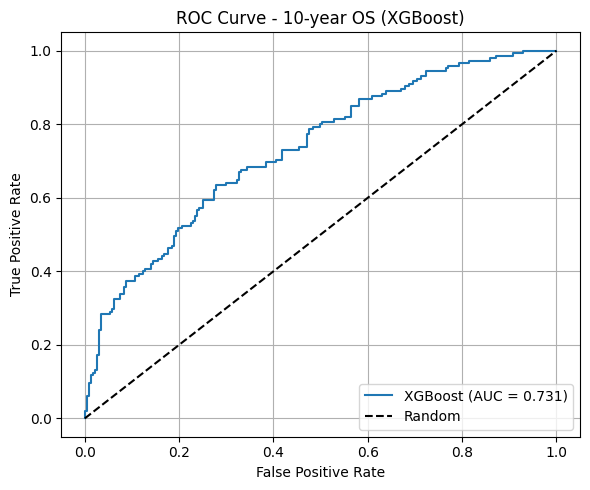

<Figure size 600x500 with 0 Axes>

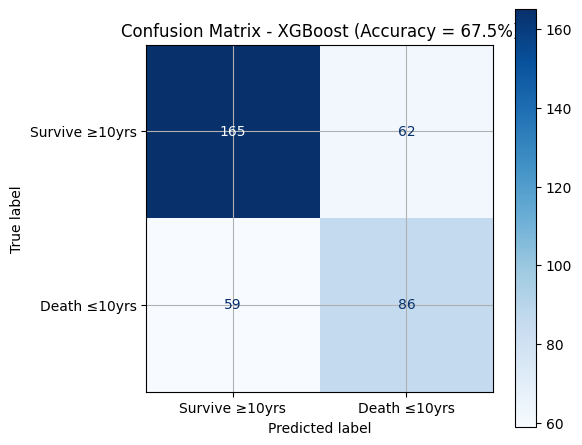

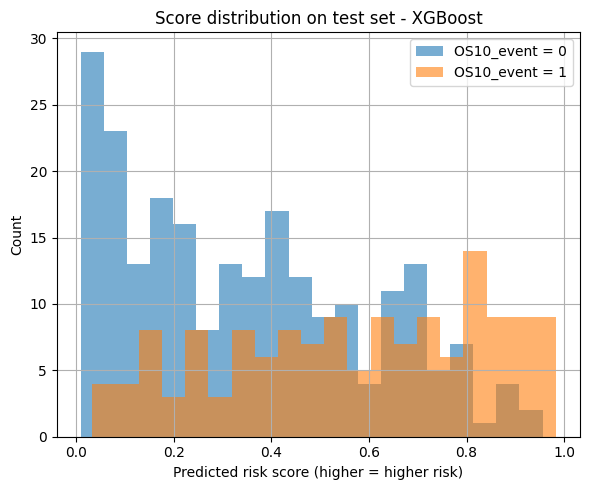

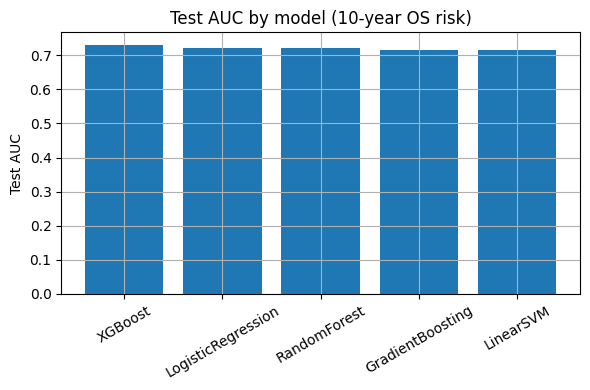

In [ ]:
# pick best model by test AUC
best_name = results_df.iloc[0]["Model"]
print("Best model by Test AUC:", best_name)

best_clf = models[best_name]
best_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", best_clf),
])

best_pipeline.fit(X_train, y_train)

if best_name == "LinearSVM":
    best_scores = best_pipeline.decision_function(X_test)
else:
    best_scores = best_pipeline.predict_proba(X_test)[:, 1]

best_pred = (best_scores >= 0.5).astype(int)
best_auc = roc_auc_score(y_test, best_scores)
best_acc = accuracy_score(y_test, best_pred)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, best_scores)
plt.figure()
plt.plot(fpr, tpr, label=f"{best_name} (AUC = {best_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - 10-year OS ({best_name})")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Confusion matrix
plt.figure()
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred,
    display_labels=["Survive ≥10yrs", "Death ≤10yrs"],
    cmap="Blues"
)
plt.title(f"Confusion Matrix - {best_name} (Accuracy = {best_acc*100:.1f}%)")
plt.tight_layout()
plt.show()

# Score distribution
plt.figure()
plt.hist(best_scores[y_test == 0], bins=20, alpha=0.6, label="OS10_event = 0")
plt.hist(best_scores[y_test == 1], bins=20, alpha=0.6, label="OS10_event = 1")
plt.xlabel("Predicted risk score (higher = higher risk)")
plt.ylabel("Count")
plt.title(f"Score distribution on test set - {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

# Test AUC bar chart for all models
plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["Test_AUC"])
plt.ylabel("Test AUC")
plt.title("Test AUC by model (10-year OS risk)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
